# BA820: Milestone IV — Clustering Refinement & Robustness Analysis
**Course:** BA820 - Unsupervised and Unstructured Machine Learning  
**Author:** Sanskruti Pawar  

**Dataset:** Hollywood Age Gaps (age_gaps.csv)  

---

## Table of Contents

####1. Introduction & Research Objective  
####2. Summary of Prior Findings (M2/M3)
####3. Refinement Strategy & Motivation
####4. Methodology & Experimental Design
- 4.1 Decade-Level Feature Construction
- 4.2 Scaling & Clustering Framework
- 4.3 Robustness Check 1: KMeans Stability Across Seeds
- 4.4 Robustness Check 2: Cross-Algorithm Agreement (Ward vs KMeans)
####5. Results
- 5.1 Stability Metrics (Silhouette & ARI)
- 5.2 Cross-Method Comparison
####6. Final Interpretation & Limitations

##1. Introduction & Research Objective

This project examines whether decades in the Hollywood Age Gap dataset cluster into distinct structural regimes based on the distribution of age differences in romantic pairings. Rather than analyzing individual films, the unit of analysis is the decade. Each decade is represented using summary statistics that capture central tendency, dispersion, and tail behavior of age gaps.

Prior milestones identified potential regime-level clustering patterns using KMeans and hierarchical clustering. However, unsupervised methods can be sensitive to initialization and algorithm choice. The objective of this milestone is to strengthen the credibility of earlier findings by testing stability across random seeds and quantifying agreement between clustering algorithms. This refinement evaluates whether the identified decade-level regimes reflect genuine structural separation rather than modeling artifacts.

##2. Summary of Prior Findings (M2/M3)

In prior milestones, decade-level distributional summaries of age gaps were constructed and analyzed using unsupervised clustering methods. The results suggested that decades cluster into distinct structural regimes rather than forming a smooth temporal progression. KMeans with 𝑘=3 produced interpretable groupings, and Ward hierarchical clustering showed similar structural patterns.

However, these findings were based primarily on single clustering runs and qualitative comparison. Stability across random initializations and formal cross-method agreement were not quantitatively evaluated. As a result, although regime patterns appeared plausible, their methodological robustness required further validation.

##3. Refinement Strategy & Motivation

Although prior milestones identified decade-level clustering patterns, the conclusions were based on limited robustness testing. KMeans can be sensitive to random initialization, and clustering results may vary depending on algorithm choice. Without formal validation, it remains unclear whether the identified regime structure reflects genuine separation or modeling artifacts.

This milestone therefore focuses on strengthening methodological credibility rather than introducing new models. Two robustness dimensions are evaluated:

- Stability Across Random Seeds: KMeans is repeated across multiple initializations, and consistency is quantified using the Adjusted Rand Index (ARI).

- Cross-Algorithm Agreement: Cluster assignments from KMeans are compared to those from Ward hierarchical clustering to assess algorithm dependence.

By testing stability and cross-method agreement, this refinement evaluates whether the previously identified decade-level regimes represent structurally distinct clusters rather than initialization-driven outcomes.

###Data Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/age_gaps.csv")
df.head()


,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


##4. Methodology & Experimental Design

###4.1 Decade-Level Feature Construction

The unit of analysis is the decade rather than individual films. Each decade is represented using distributional summaries of age differences, including measures of central tendency (mean, median), dispersion (standard deviation), tail behavior (10th and 90th percentiles), and the prevalence of large gaps (proportion ≥10 and ≥20 years).

This aggregation captures both typical and extreme age-gap patterns, enabling structural comparison across time periods and supporting regime-level clustering rather than film-specific variation.

In [ ]:
df["decade"] = (df["release_year"] // 10) * 10

decade_features = df.groupby("decade")["age_difference"].agg(
    mean_gap="mean",
    median_gap="median",
    std_gap="std",
    p90_gap=lambda x: np.percentile(x, 90),
    p10_gap=lambda x: np.percentile(x, 10),
    pct_10plus=lambda x: np.mean(x >= 10),
    pct_20plus=lambda x: np.mean(x >= 20),
    count="count"
).reset_index()

decade_features


,decade,mean_gap,median_gap,std_gap,p90_gap,p10_gap,pct_10plus,pct_20plus,count
0,1930,11.571429,12.0,6.876461,19.8,4.6,0.571429,0.142857,7
1,1940,20.250000,25.0,9.440002,25.0,7.3,0.833333,0.666667,12
2,1950,19.352941,21.0,8.495569,30.0,7.3,0.823529,0.588235,34
3,1960,9.600000,7.0,6.376427,18.6,3.0,0.457143,0.085714,35
4,1970,15.300000,14.5,10.488582,24.2,4.9,0.633333,0.366667,30
5,1980,14.420000,13.5,9.084838,28.1,3.0,0.640000,0.280000,50
6,1990,10.445946,8.0,8.924229,21.0,2.0,0.423423,0.153153,222
7,2000,9.268949,7.0,8.030947,20.0,1.0,0.371638,0.102689,409
8,2010,9.431953,7.5,7.676109,20.0,1.7,0.420118,0.103550,338
9,2020,13.555556,12.5,8.008982,23.5,4.5,0.666667,0.277778,18


###Interpretation:

The decade-level summaries reveal clear variation across time:

- Earlier decades (e.g., 1940s–1950s) show higher mean age gaps and a greater proportion of gaps ≥20 years.

- Mid-to-late decades (e.g., 1990s–2010s) exhibit smaller average gaps and lower prevalence of extreme differences.

- Dispersion (standard deviation) and upper-tail behavior (90th percentile) vary meaningfully across decades.

These patterns suggest structural heterogeneity across time periods and support the use of clustering to identify potential regime-level differences.

###4.2 Scaling & Clustering Framework

Because clustering algorithms are sensitive to feature scale, all features were standardized using the StandardScaler to ensure comparability across metrics. The primary clustering method is KMeans with 𝑘 = 3, consistent with prior milestones for comparability of results.

Cluster quality is evaluated using the silhouette score, which measures within cluster cohesion relative to between cluster separation. Additionally, stability and agreement are evaluated using the Adjusted Rand Index (ARI), a metric that quantifies similarity between clustering solutions while adjusting for chance agreement.

In [ ]:
feature_cols = ["mean_gap","median_gap","std_gap","p90_gap","p10_gap","pct_10plus","pct_20plus"]

X = decade_features[feature_cols].copy()

scaler = StandardScaler()
X_standard = scaler.fit_transform(X)

print("Clustering matrix shape:", X.shape)


Clustering matrix shape: (10, 7)


###4.3 Robustness Check 1: KMeans Stability Across Random Seeds

KMeans clustering can be sensitive to random initialization of centroids. To assess robustness, clustering is repeated across 30 different random seeds. For each run, silhouette scores are recorded and pairwise Adjusted Rand Index (ARI) values are computed across all clustering solutions.

High ARI values (~1) indicate consistent cluster assignments across initializations, suggesting that the identified structure is not driven by randomness.


In [ ]:
def kmeans_labels_across_seeds(X_scaled, k=3, seeds=range(30)):
    labels_by_seed = {}
    sil_by_seed = {}

    for s in seeds:
        km = KMeans(n_clusters=k, random_state=s, n_init=10)
        labels = km.fit_predict(X_scaled)
        labels_by_seed[s] = labels
        sil_by_seed[s] = silhouette_score(X_scaled, labels)

    return labels_by_seed, sil_by_seed

labels_km, sil_km = kmeans_labels_across_seeds(X_standard, k=3, seeds=range(30))

print("Silhouette (KMeans) mean:", np.mean(list(sil_km.values())))
print("Silhouette (KMeans) min :", np.min(list(sil_km.values())))
print("Silhouette (KMeans) max :", np.max(list(sil_km.values())))


Silhouette (KMeans) mean: 0.45051636125087846
Silhouette (KMeans) min : 0.45051636125087846
Silhouette (KMeans) max : 0.45051636125087846


In [ ]:
seeds = list(labels_km.keys())
ari_scores = []

for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):
        ari_scores.append(adjusted_rand_score(labels_km[seeds[i]], labels_km[seeds[j]]))

print("KMeans Stability ARI mean:", np.mean(ari_scores))
print("KMeans Stability ARI min :", np.min(ari_scores))
print("KMeans Stability ARI max :", np.max(ari_scores))


KMeans Stability ARI mean: 1.0
KMeans Stability ARI min : 1.0
KMeans Stability ARI max : 1.0


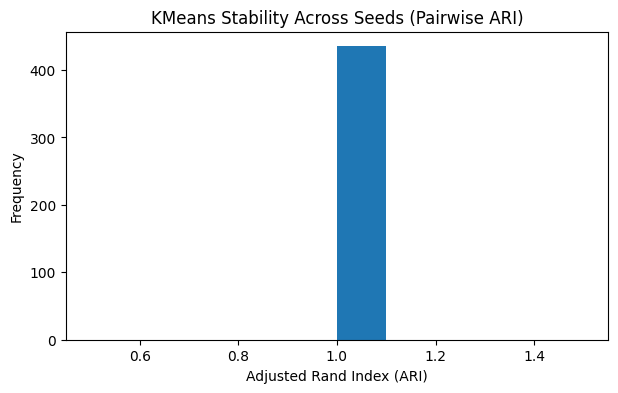

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(ari_scores, bins=10)
plt.title("KMeans Stability Across Seeds (Pairwise ARI)")
plt.xlabel("Adjusted Rand Index (ARI)")
plt.ylabel("Frequency")
plt.show()


###Interpretation

The stability analysis indicates that cluster assignments are identical across all random initializations (mean ARI = 1.00). Silhouette scores remain constant across runs, suggesting that the clustering structure is not sensitive to centroid initialization.

###4.4 Robustness Check 2: Cross-Algorithm Agreement (KMeans vs Ward)

To evaluate whether clustering results depend on the choice of algorithm, cluster assignments from KMeans (using a fixed reference seed) are compared to those produced by Ward hierarchical clustering. Agreement between the two methods is quantified using the Adjusted Rand Index (ARI).

High ARI values indicate that the identified decade-level structure is consistent across algorithmic approaches, suggesting that the clustering pattern reflects genuine separability in the feature space rather than method specific artifacts.

In [ ]:
k = 3
km_ref = KMeans(n_clusters=k, random_state=0, n_init=10)
labels_km = km_ref.fit_predict(X_standard)

ward = AgglomerativeClustering(n_clusters=k, linkage="ward")
labels_ward = ward.fit_predict(X_standard)

print("=== Cross-Method Comparison ===")
print(f"KMeans silhouette: {silhouette_score(X_standard, labels_km):.3f}")
print(f"Ward silhouette: {silhouette_score(X_standard, labels_ward):.3f}")
print(f"ARI (KMeans vs Ward): {adjusted_rand_score(labels_km, labels_ward):.3f}")


=== Cross-Method Comparison ===
KMeans silhouette: 0.451
Ward silhouette: 0.451
ARI (KMeans vs Ward): 1.000


###Interpretation:

The cross-method comparison shows identical cluster assignments between KMeans and Ward hierarchical clustering (ARI = 1.00). Silhouette scores are also identical across methods, indicating that the identified clustering structure is not dependent on algorithm choice.


## Cluster Assignment Table
This helps interpret decade-level regime membership.


In [ ]:

results = decade_features[["decade"]].copy()
results["kmeans_cluster"] = labels_km
results["ward_cluster"] = labels_ward
results


,decade,kmeans_cluster,ward_cluster
0,1930,1,0
1,1940,2,2
2,1950,2,2
3,1960,1,0
4,1970,0,1
5,1980,0,1
6,1990,1,0
7,2000,1,0
8,2010,1,0
9,2020,0,1


####Note:
Although cluster labels differ numerically between methods (e.g., 0 vs 1), the Adjusted Rand Index of 1.00 confirms that cluster assignments are structurally identical up to label permutation.

##5. Results

###5.1 Stability Metrics (Silhouette & ARI)

- Across 30 random seeds, KMeans produced identical cluster assignments (mean ARI = 1.00). Silhouette scores remained constant at 0.451, indicating complete stability with respect to initialization.

###5.2 Cross-Method Comparison

- Ward hierarchical clustering produced identical cluster assignments to KMeans (ARI = 1.00), with matching silhouette scores. Together, these findings indicate that the identified decade-level clustering structure is fully stable across both initialization and algorithm choice.

##6. Final Interpretation & Limitations

The robustness analysis demonstrates complete stability across both random initialization and clustering algorithms. Perfect agreement across seeds and between KMeans and Ward indicates that the identified decade-level clusters are not artifacts of modeling choices. Instead, decades occupy clearly separated regions in feature space, supporting the interpretation of distinct structural regimes in age-gap patterns.

However, the analysis is conducted on a relatively small number of decades, which may naturally increase structural separability. Additionally, clustering results depend on the chosen distributional features used to represent each decade. Future work could explore alternative feature constructions or finer temporal bins to further assess the sensitivity of the identified regime structure.

---